# Clustering Embeddings

This notebook shows how to explore a model's embedding space with **clustering**.
After generating embeddings we (1) run bacpipe's built-in clustering pipeline,
which groups the embeddings with K-means and compares the resulting cluster labels
against both the ground-truth annotations and the automatically generated metadata
labels using the AMI/ARI scores, and (2) plug in your own clustering algorithm
(e.g. sklearn's `KMeans`) together with a Silhouette-score evaluation. Finally we
project the embeddings to 2D with PCA to visualize the clusters.


Make sure to reset your config and settings files before running this notebook, 
as they may contain settings from previous runs that could prevent this notebook 
from finding the correct paths.

---
## 1. Setup & Configuration
Import necessary modules 

In [1]:
# to run successfully the packages for jupyter notebook need to be installed:
# uv pip install ipykernel, ipython

from IPython.display import display
import os 
from pathlib import Path

# load the specific package
import bacpipe

/home/siriussound/Code/testing_repos/bacpipe/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/siriussound/Code/testing_repos/bacpipe/bacpipe/embedding_evaluation/visualization/dashboard.py:42: UserWarning: Using Panel interactively in VSCode notebooks requires the jupyter_bokeh package to be installed. You can install it with:

   pip install jupyter_bokeh

or:
    conda install jupyter_bokeh

and try again.
  pn.extension("plotly")


Set the working directory to the repository root and clean the previous tests if needed/wanted

In [2]:
import importlib.resources as pkg_resources
os.chdir(pkg_resources.files("bacpipe"))
os.chdir('..')
print(os.listdir('.'))

# Change the value of the key main_results_dir in the namespace bacpipe.settings to change the directory 
# where the results of the tutorials are stored. By default, it is set to './bacpipe_results'.
bacpipe.settings.main_results_dir = str(Path(bacpipe.settings.main_results_dir) / 'clustering')

# !WARNING! the following code deletes the folder where the results of this tutorial is stored to be sure to start with a clean folder. 
# If you have important data in this folder, please comment it before running this code.
folder_path = bacpipe.settings.main_results_dir
if os.path.exists(folder_path):
    # Prompt the user
    user_input = input(f"Are you sure you want to delete '{folder_path}'? (y/n): ").lower().strip()

    if user_input == 'y':
        import shutil
        shutil.rmtree(folder_path) 
        print(f"Folder {folder_path} deleted.")
    else:
        print("Operation cancelled.")

else:
    print(f"Folder {folder_path} not found.")

['.vscode', 'bacpipe_results', 'run_pipeline.py', 'embed_obj = bacpipe.py', '.gitignore', 'bacpipe', '.readthedocs.yml', '.python-version', '.pytest_cache', 'pyproject.toml', 'bacpipe_model_checkpoints', '.github', '.coverage', '.venv', 'LICENSE', 'requirements_no_cuda.txt', 'requirements_tf_gpu.txt', '.mypy_cache', 'env_build', '.gitattributes', 'requirements_no_tf.txt', '.pre-commit-config.yaml', 'src', 'dist', '.git', 'README.md', 'docs', 'uv.lock']
Folder bacpipe_results/clustering not found.


Set the global constants used throughout the notebook.

In [3]:
MODEL_NAME = 'birdnet'                  # name of the model to run. Supported models are in bacpipe.supported_models
AUDIO_DIR = 'bacpipe/tests/test_data'   # path to directory containing audio files

---
## 2. Clustering Pipeline

First compute the embeddings with `run_pipeline_for_single_model` before
performing the clustering. Clustering operates on the same per-segment embedding
grid as the rest of bacpipe, so the embeddings must exist before the labels can
be built.


In [4]:
embeds = bacpipe.run_pipeline_for_single_model(
    model_name=MODEL_NAME,              # name of the model to run. Supported models are in bacpipe.supported_models
    audio_dir=AUDIO_DIR,                # path to directory containing audio files  
).embeddings(return_type='array')

Checking if the selected models require a checkpoint, and if so, if the checkpoint already exists.

birdnet checkpoint exists.




###### Generating embeddings using BIRDNET ######

finding audio files: 11it [00:00, 22128.22it/s]
Found 7 number of audio files.
2026-08-26 16:48:44.090722: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-26 16:48:44.125611: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Using device='cpu'
2026-08-26 16:48:45.516306: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed cal

`bacpipe.clustering_pipeline` runs the built-in clustering evaluation pipeline:

1. It builds the ground truth from your annotations (unannotated/noise segments
   are excluded).
2. It determines the number of clusters (defaults to the number of unique labels
   in the ground truth when `n_clusters` is `None`).
3. It fits the clustering configurations enabled in
   `bacpipe.settings.clust_configs` (by default K-means).
4. It compares each clustering against the ground truth and against all
   automatically generated metadata labels (`time_of_day`, `week_of_year`,
   `day_of_year`, ...) using Adjusted Mutual Information (AMI) and Adjusted Rand
   Index (ARI).
5. It optionally adds a Silhouette score (enable `evaluate_with_silhouette` in
   the settings) and saves the results to disk.

The function returns `(clusterings, metrics)` — the cluster labels per clustering
configuration, and the dictionary of evaluation scores.


In [5]:
# Run this function after computing the embeddings 
# otherwise it is no able to find the connection between embeddings and ground truth labels
gt = bacpipe.ground_truth_by_model(
    model=MODEL_NAME, 
    audio_dir=AUDIO_DIR, 
    annotations_filename='annotations.csv',     # By default, it looks for the annotations file in AUDIO_DIR
    overwrite=False,
    return_type='dataframe'
)

# Run the clustering pipeline with the embeddings and the ground truth labels
clusterings, metrics = bacpipe.clustering_pipeline(
    model_name=MODEL_NAME, 
    ground_truth=gt,
    embeds=embeds
)

# display the metrics of the clustering
display(metrics)




                                                                                                          
The simultaneous labels column of the ground truth has values exceeding 1. This means you have multi-label ground truth annotations. If this should not be happening ensure the ground truth is created correcly.

                                                                                                          
The simultaneous labels column of the ground truth has values exceeding 1. This means you have multi-label ground truth annotations. If this should not be happening ensure the ground truth is created correcly.

getting time of day: 100%|██████████| 7/7 [00:00<00:00, 13630.51it/s]
getting time per embeddings: 7it [00:00, 4647.06it/s]
getting day of year: 100%|██████████| 7/7 [00:00<00:00, 18327.17it/s]
getting continuous timestamps: 7it [00:00, 2882.97it/s]
getting parent directory: 7it [00:00, 3664.52it/s]
getting audio file names: 7it [00:00, 7425.42it/s]:00<00:00, 49

{'AMI': {'kmeans-time_of_day': -0.008128790565641272,
  'kmeans-week_of_year': 0.5455396665171601,
  'kmeans-day_of_year': 0.5151601880384468,
  'kmeans-continuous_timestamp': -3.1726316662319325e-14,
  'kmeans-parent_directory': 0.5137352742945769,
  'kmeans-audio_file_name': 0.4882947790979685,
  'kmeans-default_classifier': 0.3643463514586359,
  'kmeans-start': -0.05074870433833174,
  'kmeans-end': -0.05074870433833174,
  'kmeans-kmeans': 1.0,
  'kmeans_no_noise-time_of_day': -0.009778911498200439,
  'kmeans_no_noise-week_of_year': 0.524638019682483,
  'kmeans_no_noise-day_of_year': 0.4932183880804355,
  'kmeans_no_noise-continuous_timestamp': -3.814628531355607e-14,
  'kmeans_no_noise-parent_directory': 0.5396869695128556,
  'kmeans_no_noise-audio_file_name': 0.38201151362572666,
  'kmeans_no_noise-default_classifier': 0.3477211499507139,
  'kmeans_no_noise-start': -0.012755619360806821,
  'kmeans_no_noise-end': -0.012755619360806821,
  'kmeans_no_noise-kmeans': 0.5522292169252604,

# Understanding the metrics

The metrics display the shared information (AMI / ARI) between different labelings.

Each automatically generated metadata label assigns a value to every embedding
(e.g. the *time of day* of the segment, the *week of the year*, ...). K-means also
assigns a label to every embedding. The agreement between these two labelings can
be quantified with AMI and ARI.

The metrics therefore include a large number of combinations:
kmeans-time_of_day,
kmeans-week_of_year,
etc.

Each shows how much the two labelings agree and can therefore highlight
correlations. For example, if `kmeans-day_of_year` has a very high value, it is
likely that the soundscape of each day is very unique and therefore embeddings
are primarily separated by the day of the recording. A high `kmeans-species`
score, in contrast, means the clusters coincide with the annotated species.

AMI and ARI are both corrected for chance: they are close to 0 for random
agreement and exactly 1 for a perfect match.


---
## 3. Custom Clustering & Evaluation

Inject your own clustering algorithms (like sklearn's `KMeans`) and evaluate their
performance using metrics like the Silhouette score.

`get_boolean_array_for_annotated_embeddings` returns a boolean mask that is `True`
for unannotated (noise) segments; `get_single_label_gt_labels` collapses the
multi-label ground truth into a single label per embedding (picking one of the
simultaneously present species). The resulting 1D label array is the ground truth
used for clustering evaluation.

`bacpipe.run_clustering` fits every algorithm in `cluster_configs` and returns the
resulting labels. When a `ground_truth` array is passed, it additionally produces
a `_no_noise` variant fitted only on the annotated (non-noise) embeddings.

`bacpipe.eval_with_silhouette` computes the Silhouette score of the embeddings
given a label assignment. The Silhouette score measures how well separated the
annotated species are in the embedding space; it is unrelated to the K-means
settings and is a purely geometric measure of cluster cohesion and separation.


In [6]:
from bacpipe.embedding_evaluation.visualization.visualize_embeddings import (
    get_boolean_array_for_annotated_embeddings,
    get_single_label_gt_labels
)
from sklearn.cluster import KMeans

# Make sure embeddings are generated
loader_obj = bacpipe.generate_embeddings(
    model_name=MODEL_NAME,
    audio_dir=AUDIO_DIR
)

# Get the embeddings as a numpy array
embeds = loader_obj.embeddings(return_type='array')

# get the 1d ground truth array for clustering
bool_noise = get_boolean_array_for_annotated_embeddings(
    gt, MODEL_NAME
)
gt_1d = get_single_label_gt_labels(
    gt, bool_noise
    )


# Run custom clustering without ground truth
clustered_points = bacpipe.run_clustering(
    embeds=embeds, 
    cluster_configs={'my_clustering': KMeans(n_clusters=6) } 
)

# Run custom clustering with ground truth for alignment/evaluation
clustered_points_gt = bacpipe.run_clustering(
    embeds=embeds, 
    cluster_configs={'my_clustering': KMeans(n_clusters=6)}, 
    ground_truth=gt_1d
)

# Evaluate embedding separation using Silhouette score. The Silhouette score uses the ground truth labels with the embeddings to comute the separation of the embeddings according to the ground truth labels. This is unrelated to the KMeans settings. It's a measure to see how separated embeddings are in regards to the ground truth annotations
metrics = bacpipe.eval_with_silhouette(
    embeds=embeds, 
    ground_truth=gt_1d
)

# display the silhouette score
display(metrics)

Checking if the selected models require a checkpoint, and if so, if the checkpoint already exists.

birdnet checkpoint exists.




###### Generating embeddings using BIRDNET ######

Finding all generated embeddings: 7it [00:00, 2437.54it/s]
Found 7 embedding files.
finding audio files: 11it [00:00, 4051.40it/s]
Found 7 number of audio files.

### Embeddings already exist. Using embeddings in bacpipe_results/clustering/test_data/embeddings/2026-08-26_16-48___birdnet-test_data ###

You have passed a multi-label ground truth array. However for visualization only one label will be displayed.



{'SS': 0.017132285982370377}

---
## 4. Display the clusters

To visualize the high-dimensional embeddings, project them to 2D with PCA (the
same idea that `dim_reduction_model='umap'` applies during the pipeline, but here
done only for plotting). Each point is one audio segment. The two plots color the
points by the ground-truth species and by the cluster labels, which makes it easy
to see whether the clusters correspond to species or to other structure in the
data (e.g. time of day).


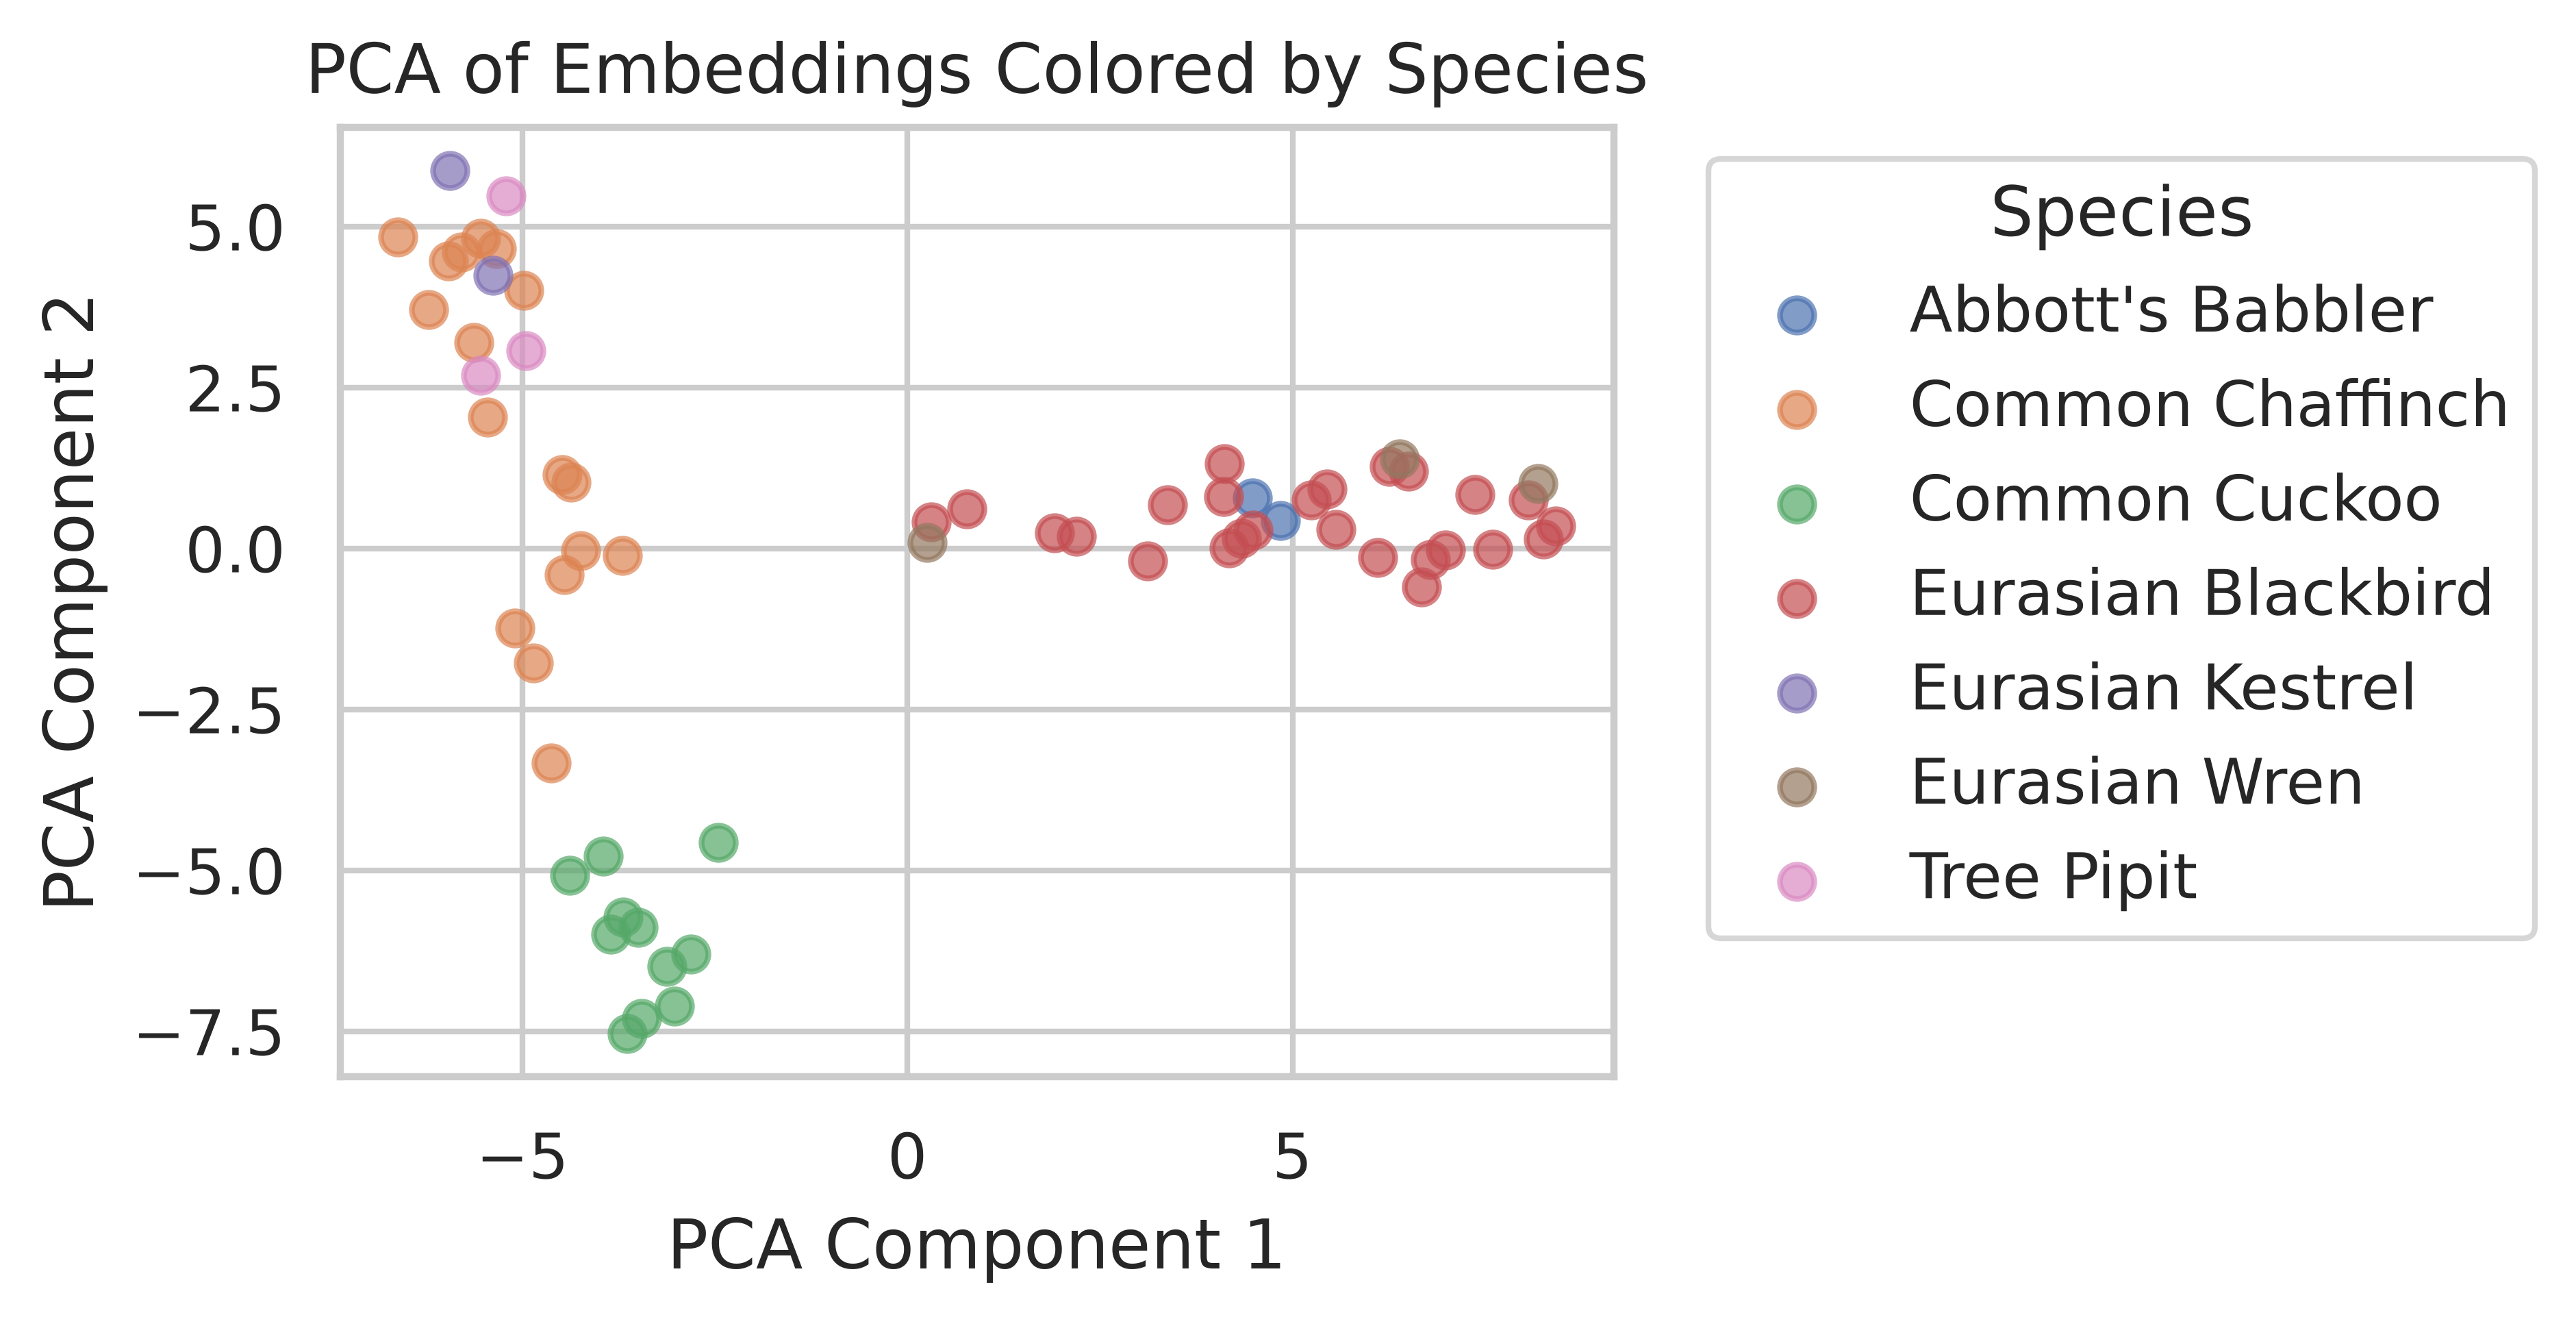

In [7]:
%matplotlib inline

# Use PCA to visualize the clusters in 2D
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# compute the PCA of the embeddings
pca = PCA(n_components=2)
embeds_2d = pca.fit_transform(embeds)

# Plot the PCA of the embeddings colored by the ground truth species labels
unique_labels = np.unique(gt_1d)

# set the figure size
plt.figure(figsize=(4, 3))

# Plot each species separately so they get their own label
for label_val in unique_labels:
    idx = np.where(gt_1d == label_val)
    plt.scatter(
        embeds_2d[idx, 0], 
        embeds_2d[idx, 1], 
        label=label_val,
        alpha=0.7 # Optional: transparency helps with overlap
    )

plt.title('PCA of Embeddings Colored by Species')
plt.legend(title="Species", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


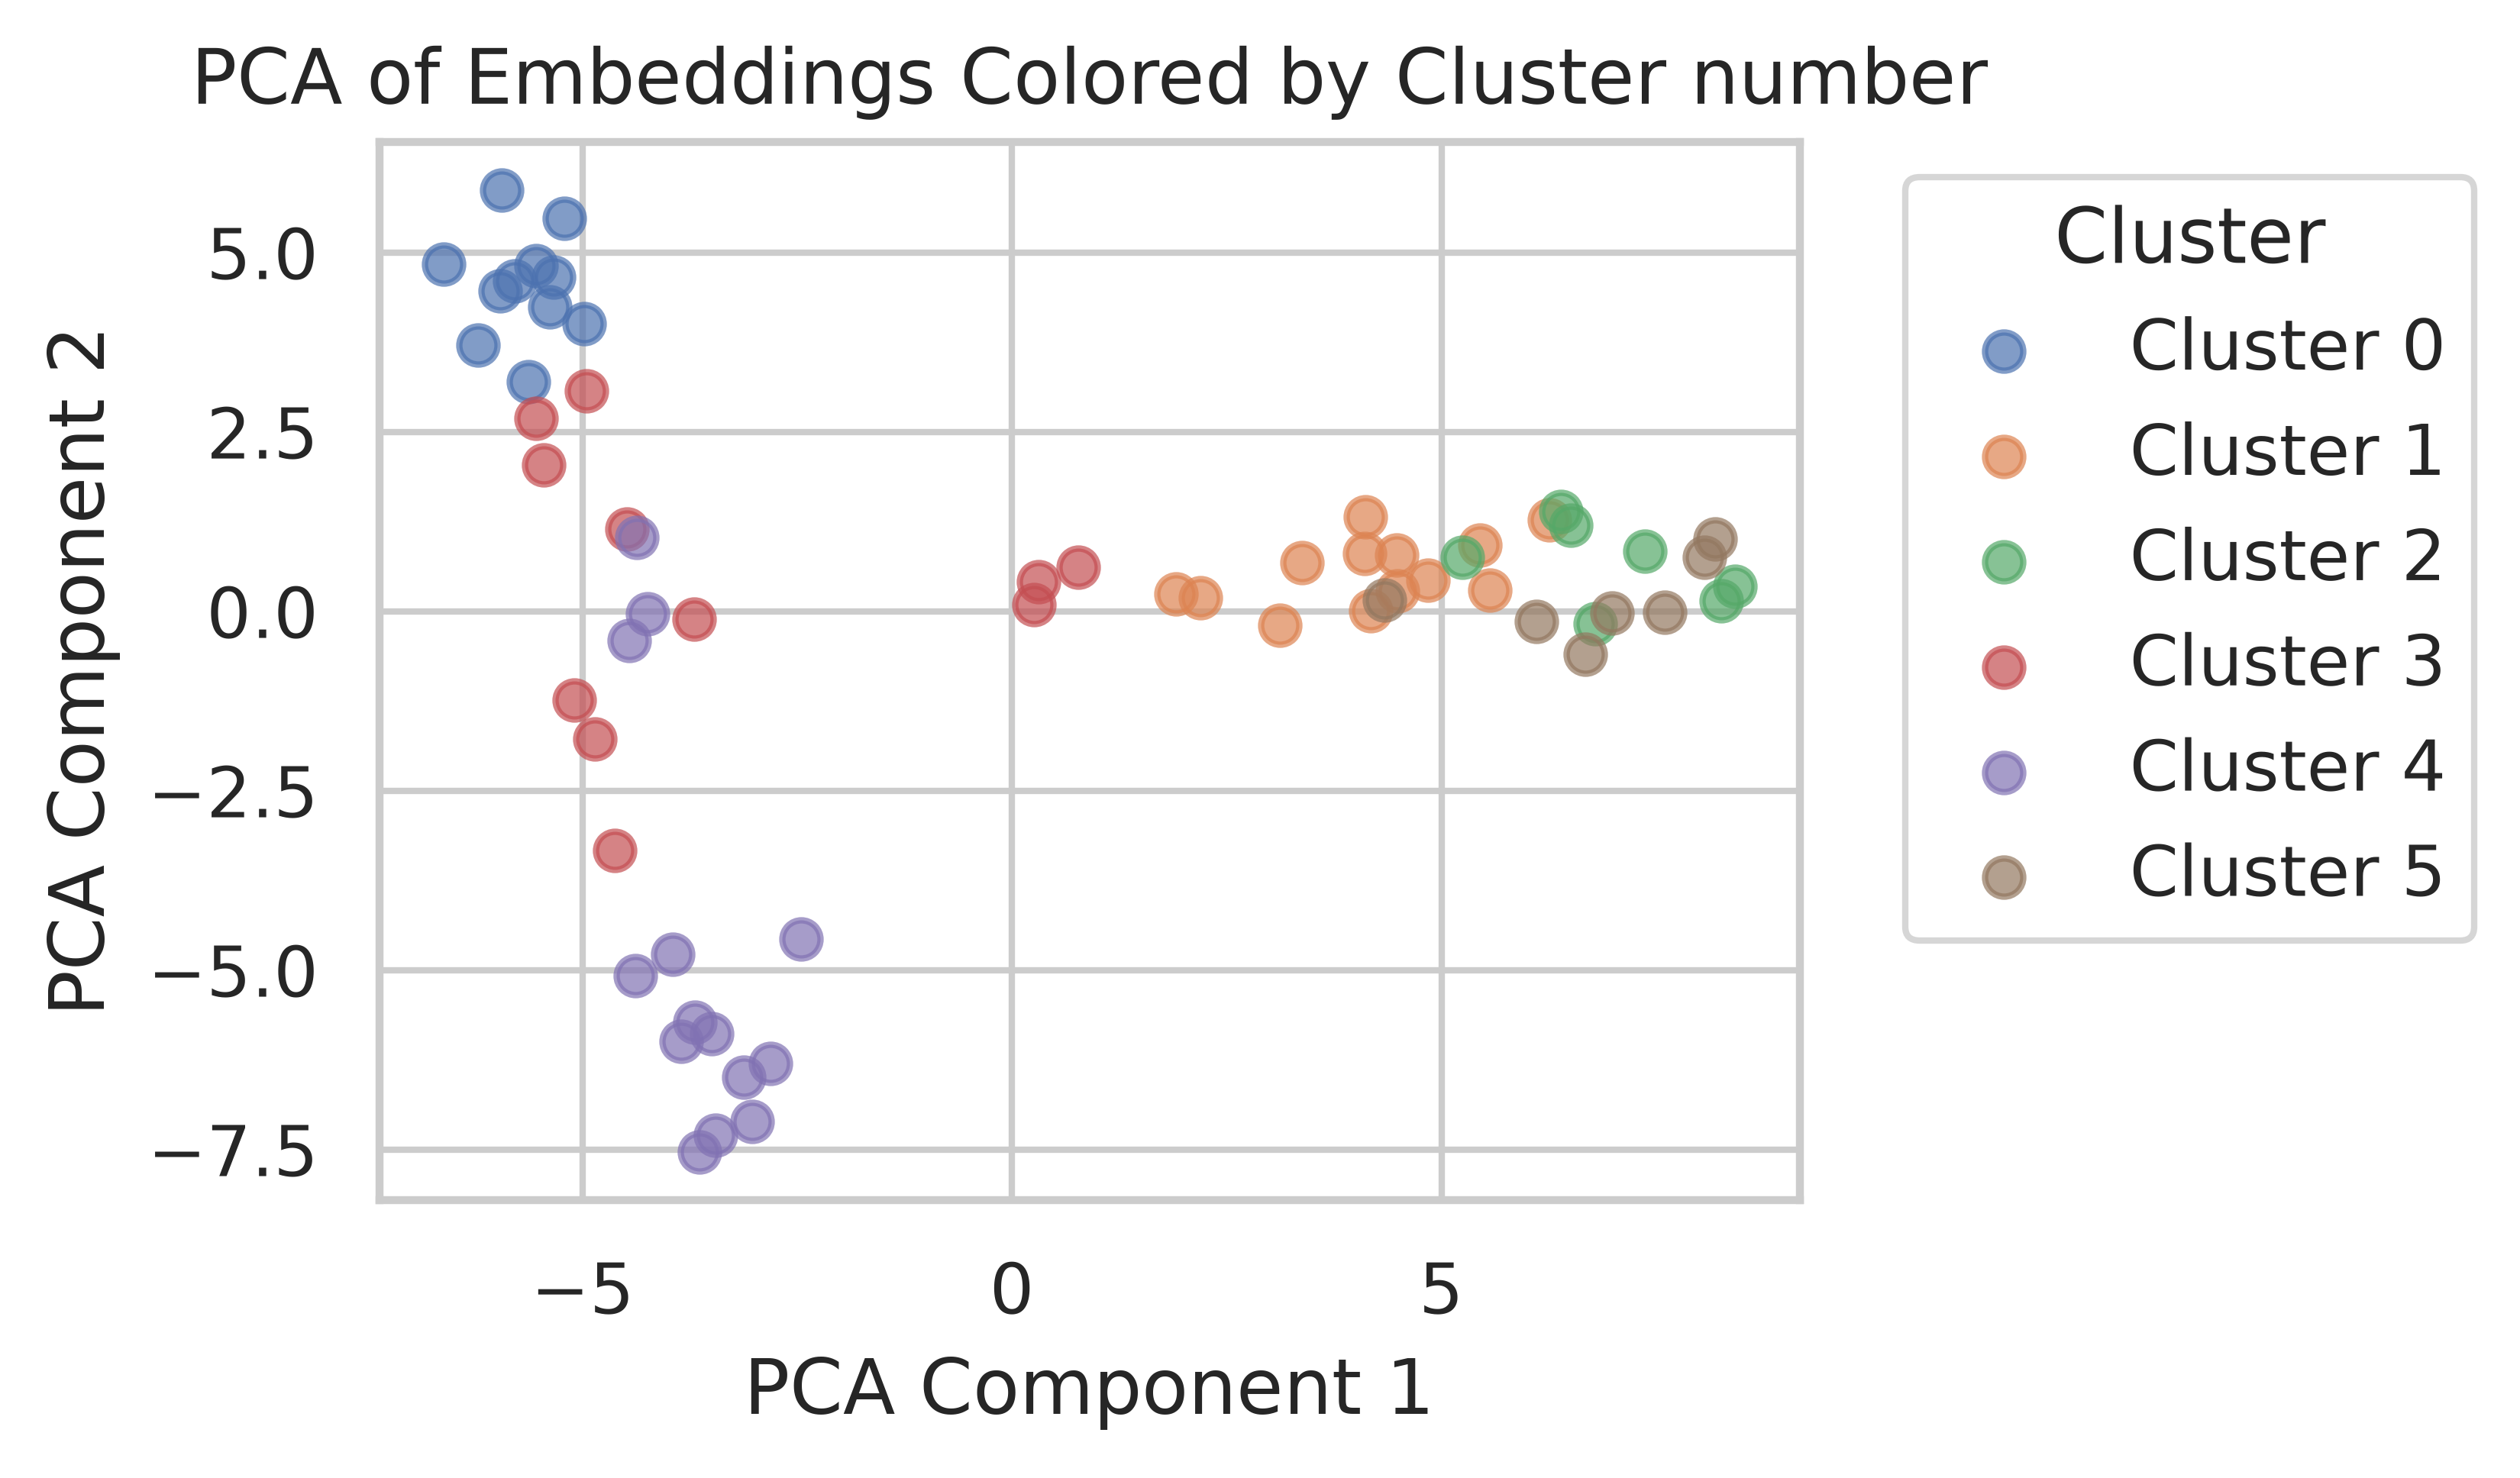

In [8]:
# Use the clustered_points as label of the points in the PCA plot
# Plot the PCA of the embeddings colored by the clustered points
labels_num = clustered_points['my_clustering']
unique_labels = np.unique(labels_num)

# set the figure size
plt.figure(figsize=(4, 3))
for label_val in unique_labels:
    idx = np.where(labels_num == label_val)
    plt.scatter(
        embeds_2d[idx, 0], 
        embeds_2d[idx, 1], 
        label=f'Cluster {label_val}',
        alpha=0.7 # Optional: transparency helps with overlap
    )
plt.title('PCA of Embeddings Colored by Cluster number')
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()
